# Baseline: четыре индикатора, target = локальный минимум ±3

Курс измеряется в рублях за единицу валюты получателя: чем он ниже, тем выгоднее момент. Индикаторы используют только информацию, известную на дату наблюдения; будущие три обновления нужны исключительно для офлайн-разметки target.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from fx_signal.baseline import build_baseline_frame

sns.set_theme(style='whitegrid')
CONFIG = Path('../configs/baseline.yaml') if Path.cwd().name == 'notebooks' else Path('configs/baseline.yaml')
frame, metrics = build_baseline_frame(CONFIG)

## Проверка данных

In [2]:
quality = frame.groupby('currency').agg(
    first_date=('effective_date', 'min'),
    last_date=('effective_date', 'max'),
    observations=('effective_date', 'size'),
    missing_price=('rub_per_unit', lambda x: x.isna().sum()),
    min_nominal=('nominal', 'min'),
    max_nominal=('nominal', 'max'),
)
quality

,first_date,last_date,observations,missing_price,min_nominal,max_nominal
currency,,,,,,
AMD,2019-01-10,2026-09-02,1888,0,100,100
KGS,2019-01-10,2026-09-02,1888,0,10,100
KZT,2019-01-10,2026-09-02,1888,0,100,100
TJS,2019-01-10,2026-09-02,1888,0,1,10
UZS,2019-01-10,2026-09-02,1888,0,1000,10000


## Target и срабатывания

In [3]:
target_col = 'target_local_min_h3'
summary = frame.groupby('currency')[target_col].agg(['count', 'sum', 'mean'])
summary.rename(columns={'count': 'eligible', 'sum': 'positives', 'mean': 'prevalence'})

,eligible,positives,prevalence
currency,,,
AMD,1882,175,0.092986
KGS,1882,176,0.093518
KZT,1882,179,0.095112
TJS,1882,170,0.090329
UZS,1882,171,0.090861


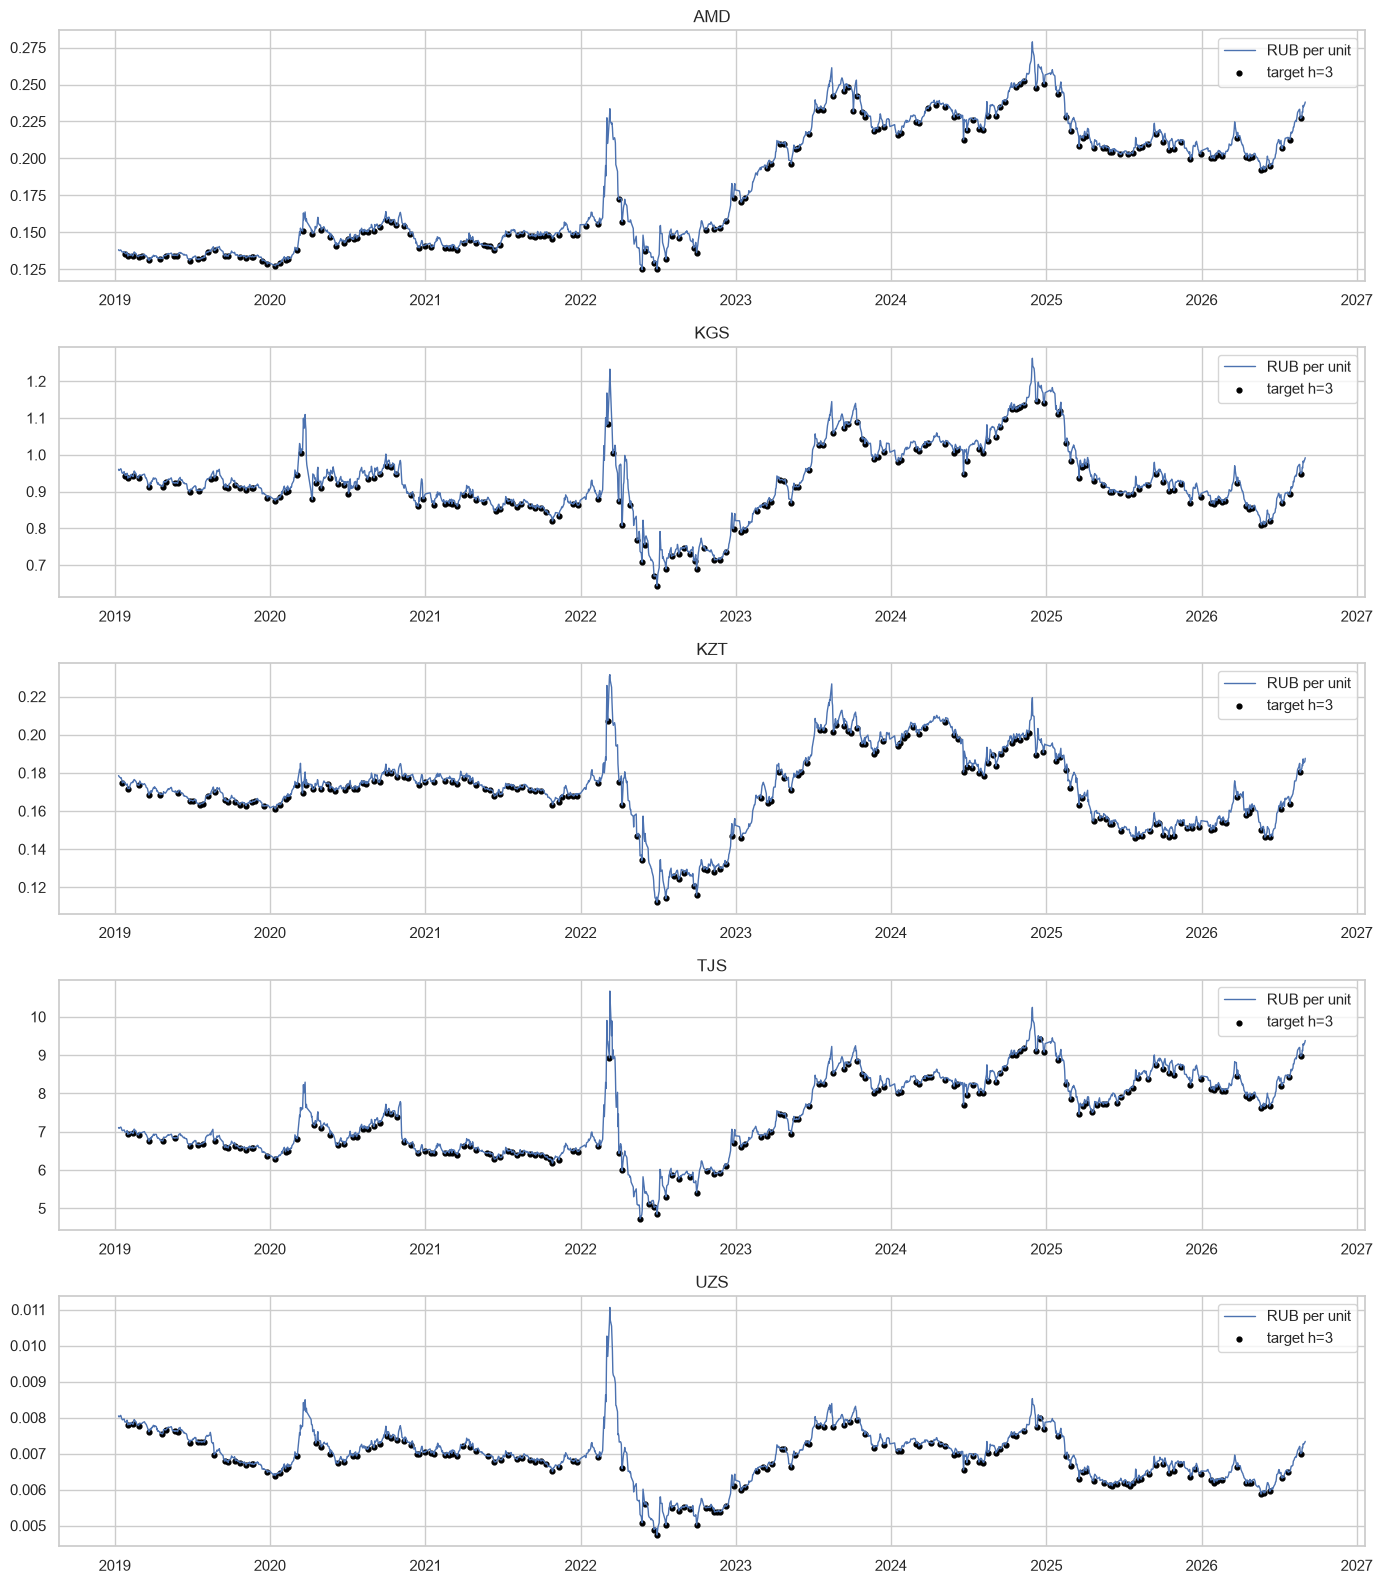

In [4]:
fig, axes = plt.subplots(5, 1, figsize=(14, 16), sharex=False)
for ax, (currency, group) in zip(axes, frame.groupby('currency')):
    ax.plot(group['effective_date'], group['rub_per_unit'], linewidth=1, label='RUB per unit')
    targets = group[group[target_col].fillna(False)]
    ax.scatter(targets['effective_date'], targets['rub_per_unit'], color='black', s=12, label='target h=3')
    ax.set_title(currency)
    ax.legend(loc='best')
fig.tight_layout()

## Hit rate и lift над случайным допустимым днём

In [5]:
metrics.sort_values(['corridor', 'lift'], ascending=[True, False]).reset_index(drop=True)

,corridor,indicator,eligible_days,signal_count,target_positives,signal_hit_rate,random_hit_rate,lift,signals_per_week
0,RUB->AMD,momentum,1796,251,166,0.306773,0.092428,3.319061,0.662020
1,RUB->AMD,level,1796,302,166,0.168874,0.092428,1.827096,0.796534
2,RUB->AMD,seasonality,1796,356,166,0.112360,0.092428,1.215649,0.938960
3,RUB->AMD,reversal,1796,87,166,0.000000,0.092428,0.000000,0.229465
4,RUB->KGS,momentum,1796,273,169,0.282051,0.094098,2.997421,0.720045
5,RUB->KGS,level,1796,361,169,0.166205,0.094098,1.766297,0.952148
6,RUB->KGS,seasonality,1796,386,169,0.111399,0.094098,1.183861,1.018086
7,RUB->KGS,reversal,1796,98,169,0.000000,0.094098,0.000000,0.258478
8,RUB->KZT,momentum,1796,249,174,0.305221,0.096882,3.150441,0.656745
9,RUB->KZT,level,1796,379,174,0.139842,0.096882,1.443423,0.999623


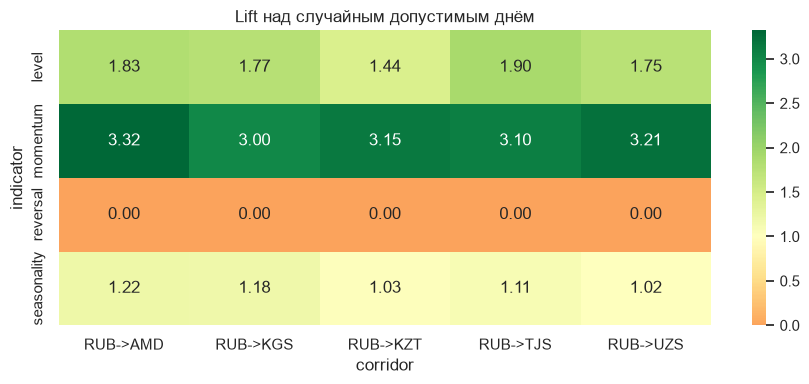

In [6]:
heatmap = metrics.pivot(index='indicator', columns='corridor', values='lift')
fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(heatmap, annot=True, fmt='.2f', center=1.0, cmap='RdYlGn', ax=ax)
ax.set_title('Lift над случайным допустимым днём')
fig.tight_layout()
repo_root = CONFIG.parent.parent
figures_dir = repo_root / 'reports' / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(figures_dir / 'baseline_lift.png', dpi=160, bbox_inches='tight')

## Как читать результат

- `lift > 1`: правило находит локальные минимумы чаще случайного допустимого дня.
- `lift ≈ 1`: правило неотличимо от обычного дня по точечной оценке.
- `lift < 1`: правило направлено хуже случайного дня относительно этого target.

У reversal получается нулевой lift по конструктивной причине: правило срабатывает после минимума, а `target_local_min_h3` требует быть минимумом именно в текущий день. Это не доказательство бесполезности разворота — его следует оценивать отдельной продуктовой метрикой `окно закрывается`, то есть последующим ростом курса.

Это стартовый описательный baseline. Доверительные интервалы, подбор параметров и строгий walk-forward добавляются следующим этапом.